# Analysis script for consistency experiments


In [1]:
## Re-parsing files to be consistent across approaches
# 
# # This uses a quick script I made to reparse the json into whatever format I am testing instead of the default 25 50 75 format.
# # this is pretty quick and dirty, but good enough for a proof of concept. 

# import subprocess, sys
# from pathlib import Path

# for path in Path("../output_data/runs").glob("*/full_results.json"):
#     out = Path("output_data/parsed") / path.parent.name / "full_results.json"
#     out.parent.mkdir(parents=True, exist_ok=True)
#     subprocess.run([sys.executable, "reparse_estimations.py", str(path), "--output", str(out)], check=True)



In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


from consistency_metrics import plot_cdf_pairs, plot_pdf_pairs, row_to_pairs, compute_pairwise_metrics

PROJECT_ROOT = Path("..").resolve()
SOURCES = {
    "main":      PROJECT_ROOT / "consistency_checks" / "output_data"/ "parsed",
    "negation":  PROJECT_ROOT / "consistency_checks" / "output_data_negation" / "parsed",
    "quantiles": PROJECT_ROOT / "consistency_checks" / "output_data_quantiles" /"parsed",
}

records = []
for source, runs_dir in SOURCES.items():
    for run_dir in sorted(runs_dir.glob("*")):
        json_path = run_dir / "full_results.json"
        if not json_path.exists():
            continue
        with open(json_path) as f:
            data = json.load(f)
        run_id = run_dir.name
        model = data["run_metadata"]["config_used"]["llm_settings"]["model"]
        for step in data["results_per_step"]:
            for task in step["results_per_task"]:
                for r in task["rounds_data"][-1]["responses"]:
                    pe = r.get("parsed_estimation", {})
                    records.append({
                        "source":    source,
                        "run_id":    run_id,
                        "model":     model,
                        "step_name": step["step_name"],
                        "task_name": task["task_name"],
                        "estimates": pe.get("estimates", {}),
                    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} responses from {df['run_id'].nunique()} runs")
display(df)


Loaded 420 responses from 140 runs


,source,run_id,model,step_name,task_name,estimates
0,main,20260301_165010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,"{'25': 0.61, '50': 0.65, '75': 0.7}"
1,main,20260301_165010,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,"{'25': 0.5, '50': 0.55, '75': 0.6}"
2,main,20260301_165010,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,"{'25': 0.85, '50': 0.87, '75': 0.89}"
3,main,20260301_165252,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,"{'25': 0.6, '50': 0.63, '75': 0.67}"
4,main,20260301_165252,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,"{'25': 0.52, '50': 0.57, '75': 0.62}"
...,...,...,...,...,...,...
415,quantiles,20260324_091605,gpt-5-mini-2025-08-07,TA0002 - Execution,Imaginairy,"{'10': 0.25, '20': 0.33, '30': 0.45, '40': 0.5..."
416,quantiles,20260324_091605,gpt-5-mini-2025-08-07,TA0007 - Discovery,Imaginairy,"{'10': 0.77, '20': 0.8, '30': 0.84, '40': 0.87..."
417,quantiles,20260324_091930,gpt-5-mini-2025-08-07,TA0001 - Initial Access,Imaginairy,"{'10': 0.33, '20': 0.45, '30': 0.56, '40': 0.6..."
418,quantiles,20260324_091930,gpt-5-mini-2025-08-07,TA0002 - Execution,Imaginairy,"{'10': 0.22, '20': 0.33, '30': 0.48, '40': 0.5..."


In [3]:
#data summaries
empty = df[df["estimates"].apply(lambda x: len(x) == 0)]
print(f"{len(empty)} responses with empty estimates")
display(empty[["source", "run_id", "model", "step_name", "task_name"]])
display(df.describe())
display(df.groupby(["source", "model", "step_name", "run_id"]).size().groupby(level=["source", "model", "step_name"]).count().rename("n_runs").reset_index())

1 responses with empty estimates


,source,run_id,model,step_name,task_name
370,quantiles,20260324_085053,gpt-5-mini-2025-08-07,TA0002 - Execution,Imaginairy


,source,run_id,model,step_name,task_name,estimates
count,420,420,420,420,420,420
unique,3,140,2,3,1,373
top,quantiles,20260301_165010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,"{'20': 0.83, '40': 0.86, '60': 0.88, '80': 0.91}"
freq,240,3,210,140,420,4


,source,model,step_name,n_runs
0,main,claude-sonnet-4-6,TA0001 - Initial Access,20
1,main,claude-sonnet-4-6,TA0002 - Execution,20
2,main,claude-sonnet-4-6,TA0007 - Discovery,20
3,main,gpt-5-mini-2025-08-07,TA0001 - Initial Access,20
4,main,gpt-5-mini-2025-08-07,TA0002 - Execution,20
5,main,gpt-5-mini-2025-08-07,TA0007 - Discovery,20
6,negation,claude-sonnet-4-6,TA0001 - Initial Access,10
7,negation,claude-sonnet-4-6,TA0002 - Execution,10
8,negation,claude-sonnet-4-6,TA0007 - Discovery,10
9,negation,gpt-5-mini-2025-08-07,TA0001 - Initial Access,10


In [4]:
display(empty)

,source,run_id,model,step_name,task_name,estimates
370,quantiles,20260324_085053,gpt-5-mini-2025-08-07,TA0002 - Execution,Imaginairy,{}


## Analysis
The purpose of this analysis is to compare the consistency across multiple variations on elicitation. The primary variations are:
- Main: standard approach with elicitation at 25 50 and 75 percentiles
- Negation: same as main, except that we are asking the model the probability of failure at these percentiles instead of success
- Quantiles: probabilities are elicited at various points other than the 25 50 75 combo. This includes variations with more than 3 points and variations with 3 points at different places.
The analysis is broken into three pieces:
1. Self-consistency across multiple runs with the same settings (for each subset: main, negation, quantiles).
    - Note that quantiles are further split based on the number and location of elicited quantiles.
2. Consistency across elicitation approaches, when compared with main.
3. A summary comparison identifying the biggest sources of variance.

In [5]:

# ── Setup: filter empties, tag quantile configs, define helpers ───────────────

df_valid = df[df["estimates"].apply(lambda x: len(x) > 0)].copy()
df_valid["quantile_config"] = df_valid["estimates"].apply(
    lambda e: tuple(sorted(int(k) for k in e.keys()))
)

def invert_estimates(estimates):
    """1 - v and mirror percentile to convert failure→success probabilities for negation runs."""
    return {str(100 - int(k)): round(1.0 - v, 10) for k, v in estimates.items() if v is not None}


print("Quantile configs present in 'quantiles' source:")
display(
    df_valid[df_valid["source"] == "quantiles"]
    .groupby(["model", "quantile_config"])
    .size()
    .reset_index(name="n_rows")
)


Quantile configs present in 'quantiles' source:


,model,quantile_config,n_rows
0,claude-sonnet-4-6,"(5, 50, 95)",30
1,claude-sonnet-4-6,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",30
2,claude-sonnet-4-6,"(13, 60, 77)",30
3,claude-sonnet-4-6,"(20, 40, 60, 80)",30
4,gpt-5-mini-2025-08-07,"(5, 50, 95)",30
5,gpt-5-mini-2025-08-07,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",29
6,gpt-5-mini-2025-08-07,"(13, 60, 77)",30
7,gpt-5-mini-2025-08-07,"(20, 40, 60, 80)",30


### Part 1 — Self-consistency within each source

For `main` and `negation`, we compare every pair of runs within each `(source, model, step_name)` group.  
For `quantiles`, we first split by quantile configuration (the set of elicited percentile levels), then do the same within each sub-group.

In [6]:
# Pick one specific model/step
target_model = df_valid["model"].iloc[0]
target_step = df_valid["step_name"].iloc[0]
target_source = "main"  # or "negation", "quantiles"

grp = df_valid[
    (df_valid["source"] == target_source)
    & (df_valid["model"] == target_model)
    & (df_valid["step_name"] == target_step)
]

# For quantiles, optionally filter to one config
# grp = grp[grp["quantile_config"] == "some_config"]

if len(grp) < 2:
    print(f"Only {len(grp)} run(s) — need at least 2 for pairwise metrics")
else:
    m = compute_pairwise_metrics(grp, include_beta=True, compute_ci=True, random_state=42)
    result = {
        "source": target_source,
        "model": target_model,
        "step_name": target_step,
        "n_runs": len(grp),
        **m,
    }
    pd.DataFrame([result]).round(4)
display(result)

{'source': 'main',
 'model': 'claude-sonnet-4-6',
 'step_name': 'TA0001 - Initial Access',
 'n_runs': 20,
 'w1': 0.01360614035087719,
 'w2': 0.01634832390971052,
 'p50_divergence': 0.012105263157894747,
 'iqr_divergence': 0.03473684210526314,
 'w1_beta': 0.025073833340658817,
 'w2_beta': 0.030005050744152224,
 'n_pairs': 190,
 'confidence_level': 0.95,
 'n_bootstrap': 1000,
 'w1_ci_lower': 0.008788547149122807,
 'w1_ci_upper': 0.016507233709273185,
 'w2_ci_lower': 0.010584959500526311,
 'w2_ci_upper': 0.0198391916252348,
 'w1_beta_ci_lower': 0.01535890935189024,
 'w1_beta_ci_upper': 0.030948543822714857,
 'w2_beta_ci_lower': 0.01800803636464241,
 'w2_beta_ci_upper': 0.03756026208192375}

In [ ]:

# ── Part 1: compute self-consistency metrics ──────────────────────────────────

rows_1 = []
for (source, model, step_name), grp in df_valid.groupby(["source", "model", "step_name"]):
    sub_groups = (
        grp.groupby("quantile_config") if source == "quantiles"
        else [("—", grp)]
    )
    for qconfig, sub in sub_groups:
        if len(sub) < 2:
            continue
        m = compute_pairwise_metrics(sub, include_beta=True, compute_ci=True, random_state=42)
        rows_1.append({
            "source": source,
            "quantile_config": str(qconfig) if source == "quantiles" else "—",
            "model": model,
            "step_name": step_name,
            "n_runs": len(sub),
            **m,
        })

sc_df = pd.DataFrame(rows_1)

# display(
#     sc_df[["source", "quantile_config", "model", "step_name",
#            "n_runs", "n_pairs",
#            "w1", "w1_ci_lower", "w1_ci_upper",
#            "w2", "w2_ci_lower", "w2_ci_upper",
#            "p50_divergence", "iqr_divergence"]]
#     .round(4)
#     .sort_values(["source", "quantile_config", "model", "step_name"])
#     .reset_index(drop=True)
# )


,source,quantile_config,model,step_name,n_runs,n_pairs,w1,w1_ci_lower,w1_ci_upper,w2,w2_ci_lower,w2_ci_upper,p50_divergence,iqr_divergence
0,main,—,claude-sonnet-4-6,TA0001 - Initial Access,20,190,0.0136,0.0088,0.0165,0.0163,0.0106,0.0198,0.0121,0.0347
1,main,—,claude-sonnet-4-6,TA0002 - Execution,20,190,0.0128,0.0087,0.0154,0.0154,0.0108,0.0183,0.0158,0.0234
2,main,—,claude-sonnet-4-6,TA0007 - Discovery,20,190,0.0059,0.0046,0.0064,0.0073,0.0058,0.0080,0.0044,0.0154
3,main,—,gpt-5-mini-2025-08-07,TA0001 - Initial Access,20,190,0.0338,0.0258,0.0381,0.0430,0.0321,0.0490,0.0258,0.0978
4,main,—,gpt-5-mini-2025-08-07,TA0002 - Execution,20,190,0.0243,0.0155,0.0306,0.0294,0.0191,0.0364,0.0287,0.0508
5,main,—,gpt-5-mini-2025-08-07,TA0007 - Discovery,20,190,0.0116,0.0082,0.0137,0.0142,0.0102,0.0165,0.0142,0.0215
6,negation,—,claude-sonnet-4-6,TA0001 - Initial Access,10,45,0.0149,0.0091,0.0162,0.0178,0.0112,0.0189,0.0178,0.0260
7,negation,—,claude-sonnet-4-6,TA0002 - Execution,10,45,0.0153,0.0098,0.0169,0.0188,0.0120,0.0206,0.0169,0.0356
8,negation,—,claude-sonnet-4-6,TA0007 - Discovery,10,45,0.0106,0.0052,0.0130,0.0123,0.0064,0.0147,0.0131,0.0116
9,negation,—,gpt-5-mini-2025-08-07,TA0001 - Initial Access,10,45,0.0261,0.0151,0.0317,0.0312,0.0182,0.0373,0.0388,0.0442


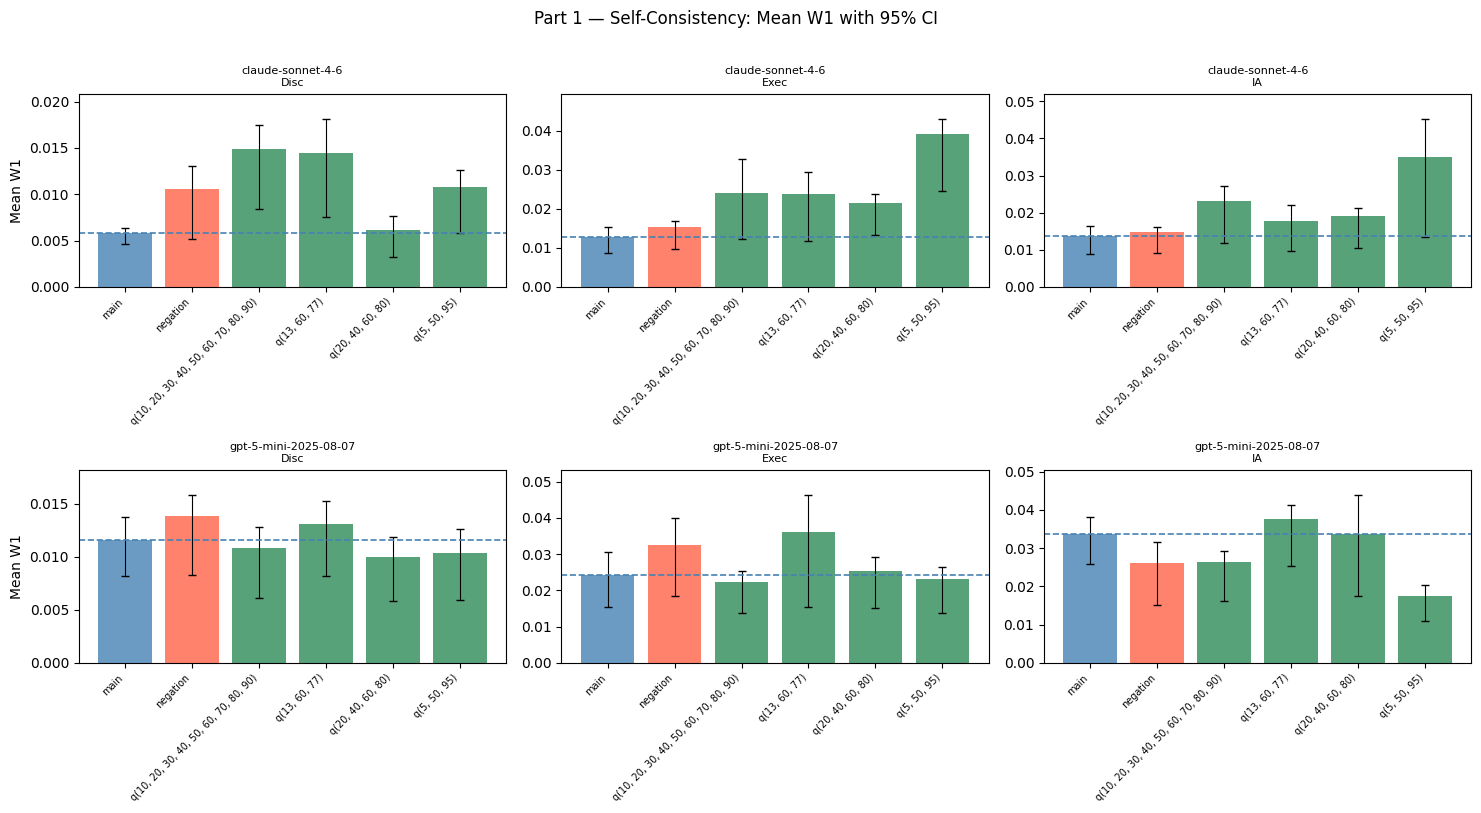

In [27]:
# ── Part 1: visualise self-consistency ───────────────────────────────────────
# Mean W1 per (source, quantile_config) broken down by model and step.

STEP_SHORT = {
    "TA0001 - Initial Access": "IA",
    "TA0002 - Execution": "Exec",
    "TA0007 - Discovery": "Disc",
}
sc_df["step_short"] = sc_df["step_name"].map(STEP_SHORT).fillna(sc_df["step_name"])

# Build a compact condition label
sc_df["condition"] = sc_df.apply(
    lambda r: r["source"] if r["quantile_config"] == "—"
    else f"q{r['quantile_config']}",
    axis=1,
)

models = sc_df["model"].unique()
steps  = sorted(sc_df["step_short"].unique())
conditions = sc_df.groupby(["source", "quantile_config"])["condition"].first().values

fig, axes = plt.subplots(len(models), len(steps),
                         figsize=(5 * len(steps), 4 * len(models)),
                         sharey=False, squeeze=False)

SOURCE_COLOR = {"main": "steelblue", "negation": "tomato", "quantiles": "seagreen"}

for row_i, model in enumerate(models):
    for col_i, step in enumerate(steps):
        ax = axes[row_i][col_i]
        sub = sc_df[(sc_df["model"] == model) & (sc_df["step_short"] == step)].copy()
        sub = sub.sort_values(["source", "quantile_config"])
        colors = [SOURCE_COLOR[s] for s in sub["source"]]
        xs = range(len(sub))
        ax.bar(xs, sub["w1"], color=colors, alpha=0.8)
        ax.errorbar(
            xs, sub["w1"],
            yerr=[sub["w1"] - sub["w1_ci_lower"], sub["w1_ci_upper"] - sub["w1"]],
            fmt="none", color="black", capsize=3, linewidth=0.8,
        )
                # dashed baseline: self-consistency of main
        bl = sub.loc[sub["source"] == "main", "w1"]
        if not bl.empty:
            ax.axhline(bl.values[0], color="steelblue", linestyle="--",
                       linewidth=1.2)

        ax.set_xticks(xs)
        ax.set_xticklabels(sub["condition"], rotation=45, ha="right", fontsize=7)
        top = (sub["w1_ci_upper"]).max() * 1.15
        ax.set_ylim(bottom=0, top=top)
        ax.set_title(f"{model}\n{step}", fontsize=8)
        if col_i == 0:
            ax.set_ylabel("Mean W1")

from matplotlib.patches import Patch
legend_elements = [Patch(color=c, label=s) for s, c in SOURCE_COLOR.items()]
fig.suptitle("Part 1 — Self-Consistency: Mean W1 with 95% CI", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


### Example of self consistency distributions

Model: claude-sonnet-4-6, Step: TA0002 - Execution


Main:


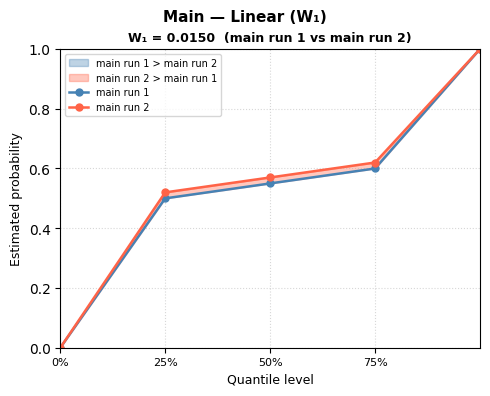

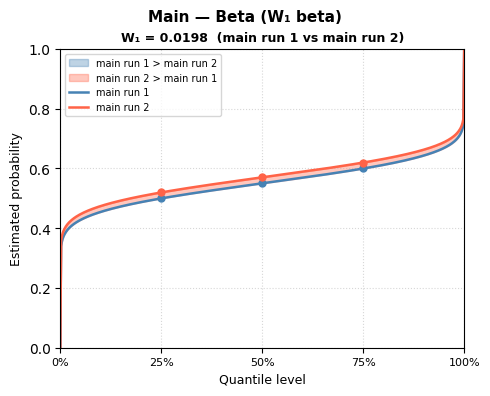


Negation (inverted):


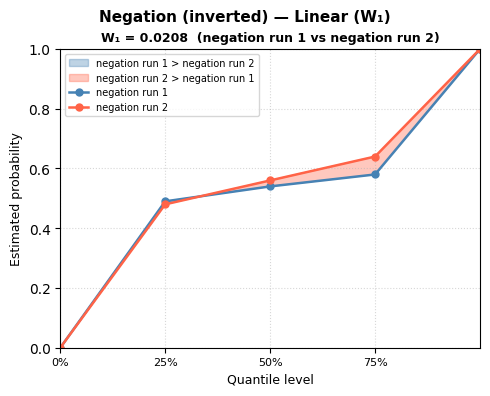

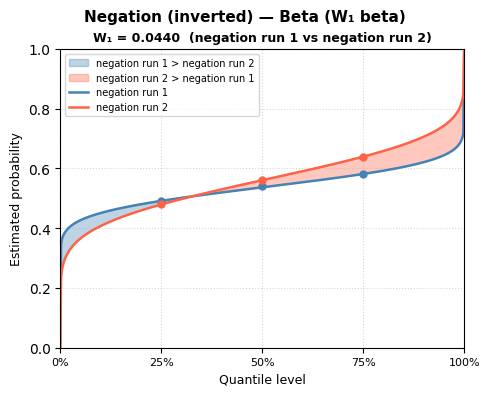


Quantiles (config (20, 40, 60, 80)):


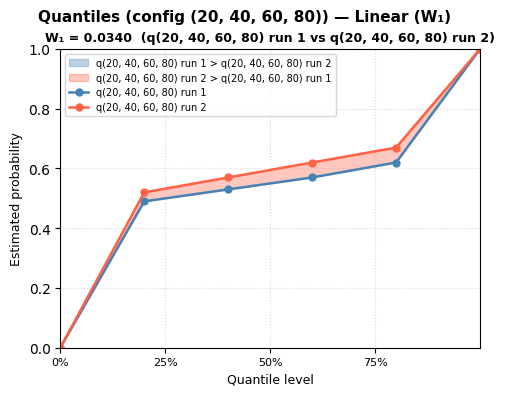

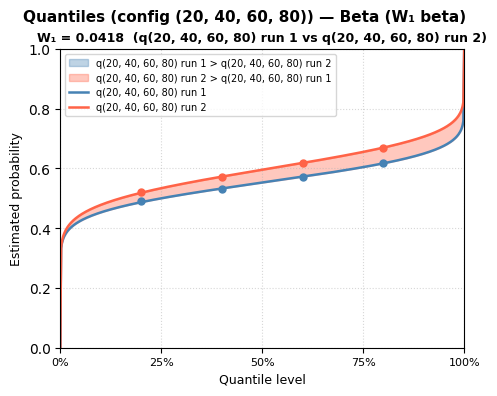

In [9]:
# ── Example CDF plots: one from each source ──────────────────────────────────
# Pick a single (model, step_name) group and show a few CDF pair comparisons.

# Choose the first available model + step combination
model_ex = df_valid["model"].iloc[1]
step_ex  = df_valid["step_name"].iloc[1]

# --- Main: grab 2 runs to show self-consistency CDF ---
main_rows = df_valid[
    (df_valid["source"] == "main")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
]
main_dists   = [row_to_pairs(r) for r in main_rows["estimates"].values[:2]]
main_labels  = [f"main run {i+1}" for i in range(len(main_dists))]

# --- Negation: grab 2 runs (inverted to success scale) ---
neg_rows = df_valid[
    (df_valid["source"] == "negation")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
].copy()
neg_rows["estimates"] = neg_rows["estimates"].apply(invert_estimates)
neg_dists   = [row_to_pairs(r) for r in neg_rows["estimates"].values[:2]]
neg_labels  = [f"negation run {i+1}" for i in range(len(neg_dists))]

# --- Quantiles: grab 2 runs from the first available config ---
quant_rows = df_valid[
    (df_valid["source"] == "quantiles")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
]
qconfig_ex   = quant_rows["quantile_config"].iloc[0]
quant_subset = quant_rows[quant_rows["quantile_config"] == qconfig_ex]
quant_dists  = [row_to_pairs(r) for r in quant_subset["estimates"].values[:2]]
quant_labels = [f"q{qconfig_ex} run {i+1}" for i in range(len(quant_dists))]

# --- Plot all three as separate figures ---
print(f"Model: {model_ex}, Step: {step_ex}\n")

for source_name, dists, labels in [
    ("Main", main_dists, main_labels),
    ("Negation (inverted)", neg_dists, neg_labels),
    (f"Quantiles (config {qconfig_ex})", quant_dists, quant_labels),
]:
    print(f"\n{source_name}:")

    fig_lin = plot_cdf_pairs(dists, labels_a=labels, use_beta=False)
    fig_lin.suptitle(f"{source_name} — Linear (W₁)", fontsize=11, fontweight="bold")
    fig_lin.subplots_adjust(top=0.88)
    plt.show()

    fig_beta = plot_cdf_pairs(dists, labels_a=labels, use_beta=True)
    fig_beta.suptitle(f"{source_name} — Beta (W₁ beta)", fontsize=11, fontweight="bold")
    fig_beta.subplots_adjust(top=0.88)
    plt.show()

# print(f"Model: {model_ex}, Step: {step_ex}\n")

# print("Main self-consistency:")
# fig_main = plot_cdf_pairs(main_dists, labels_a=main_labels, use_beta=False)
# fig_main.subplots_adjust(top=0.88)
# print(main_dists)
# plt.show()

# print(f"\nNegation self-consistency (inverted to success scale):")
# fig_neg = plot_cdf_pairs(neg_dists, labels_a=neg_labels, use_beta=False)
# fig_neg.subplots_adjust(top=0.88)
# print(neg_dists)
# plt.show()

# print(f"\nQuantiles self-consistency (config {qconfig_ex}):")
# fig_quant = plot_cdf_pairs(quant_dists, labels_a=quant_labels, use_beta=False)
# fig_quant.subplots_adjust(top=0.88)
# print(quant_dists)
# plt.show()


### Part 2 — Consistency across elicitation approaches vs main

**Negation vs main**: negation estimates express P(failure); we invert them (1 − v) to put them on the same success-probability scale before comparison.  
**Quantile variants vs main**: each distinct quantile configuration in the `quantiles` source is compared against all `main` runs for the same `(model, step_name)`.

All cross-approach comparisons compute every cross-product pair (one from each source), so the resulting mean W1/W2 can be directly compared to the self-consistency baselines from Part 1.

In [11]:

# ── Part 2: cross-approach consistency ───────────────────────────────────────

main_df = df_valid[df_valid["source"] == "main"]

neg_df = df_valid[df_valid["source"] == "negation"].copy()
neg_df["estimates"] = neg_df["estimates"].apply(invert_estimates)

quant_df = df_valid[df_valid["source"] == "quantiles"]

rows_2 = []

# 2a: negation (inverted) vs main
for (model, step_name), main_grp in main_df.groupby(["model", "step_name"]):
    neg_grp = neg_df[
        (neg_df["model"] == model) & (neg_df["step_name"] == step_name)
    ]
    if neg_grp.empty:
        continue
    n = min(len(main_grp), len(neg_grp))
    m = compute_pairwise_metrics(
        main_grp.sample(n, random_state=42).reset_index(drop=True),
        neg_grp.sample(n, random_state=42).reset_index(drop=True),
        include_beta=True,
        compute_ci=True,
    )
    rows_2.append({
        "comparison": "negation_vs_main",
        "quantile_config": "—",
        "model": model,
        "step_name": step_name,
        "n_a": len(main_grp),
        "n_b": len(neg_grp),
        **m,
    })

# 2b: each quantile config vs main
for (model, step_name, qconfig), q_grp in quant_df.groupby(
    ["model", "step_name", "quantile_config"]
):
    main_grp = main_df[
        (main_df["model"] == model) & (main_df["step_name"] == step_name)
    ]
    if main_grp.empty:
        continue
    n = min(len(main_grp), len(q_grp))
    m = compute_pairwise_metrics(
        main_grp.sample(n, random_state=42).reset_index(drop=True),
        q_grp.sample(n, random_state=42).reset_index(drop=True),
        include_beta=True,
        compute_ci=True,
    )
    rows_2.append({
        "comparison": "quantiles_vs_main",
        "quantile_config": str(qconfig),
        "model": model,
        "step_name": step_name,
        "n_a": len(main_grp),
        "n_b": len(q_grp),
        **m,
    })

cross_df = pd.DataFrame(rows_2)

display(
    cross_df[["comparison", "quantile_config", "model", "step_name",
              "n_a", "n_b", "n_pairs",
              "w1", "w2", "p50_divergence", "iqr_divergence"]]
    .round(4)
    .sort_values(["comparison", "quantile_config", "model", "step_name"])
    .reset_index(drop=True)
)


,comparison,quantile_config,model,step_name,n_a,n_b,n_pairs,w1,w2,p50_divergence,iqr_divergence
0,negation_vs_main,—,claude-sonnet-4-6,TA0001 - Initial Access,20,10,100,0.0155,0.0188,0.0140,0.0414
1,negation_vs_main,—,claude-sonnet-4-6,TA0002 - Execution,20,10,100,0.0162,0.0196,0.0160,0.0428
2,negation_vs_main,—,claude-sonnet-4-6,TA0007 - Discovery,20,10,100,0.0083,0.0098,0.0090,0.0146
3,negation_vs_main,—,gpt-5-mini-2025-08-07,TA0001 - Initial Access,20,10,100,0.0403,0.0505,0.0341,0.0863
4,negation_vs_main,—,gpt-5-mini-2025-08-07,TA0002 - Execution,20,10,100,0.0309,0.0367,0.0378,0.0568
5,negation_vs_main,—,gpt-5-mini-2025-08-07,TA0007 - Discovery,20,10,100,0.0151,0.0186,0.0161,0.0377
6,quantiles_vs_main,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",claude-sonnet-4-6,TA0001 - Initial Access,20,10,100,0.0568,0.0854,0.0100,0.0514
7,quantiles_vs_main,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",claude-sonnet-4-6,TA0002 - Execution,20,10,100,0.0575,0.0809,0.0200,0.0499
8,quantiles_vs_main,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",claude-sonnet-4-6,TA0007 - Discovery,20,10,100,0.0639,0.1265,0.0068,0.0303
9,quantiles_vs_main,"(10, 20, 30, 40, 50, 60, 70, 80, 90)",gpt-5-mini-2025-08-07,TA0001 - Initial Access,20,10,100,0.0467,0.0599,0.0332,0.0877


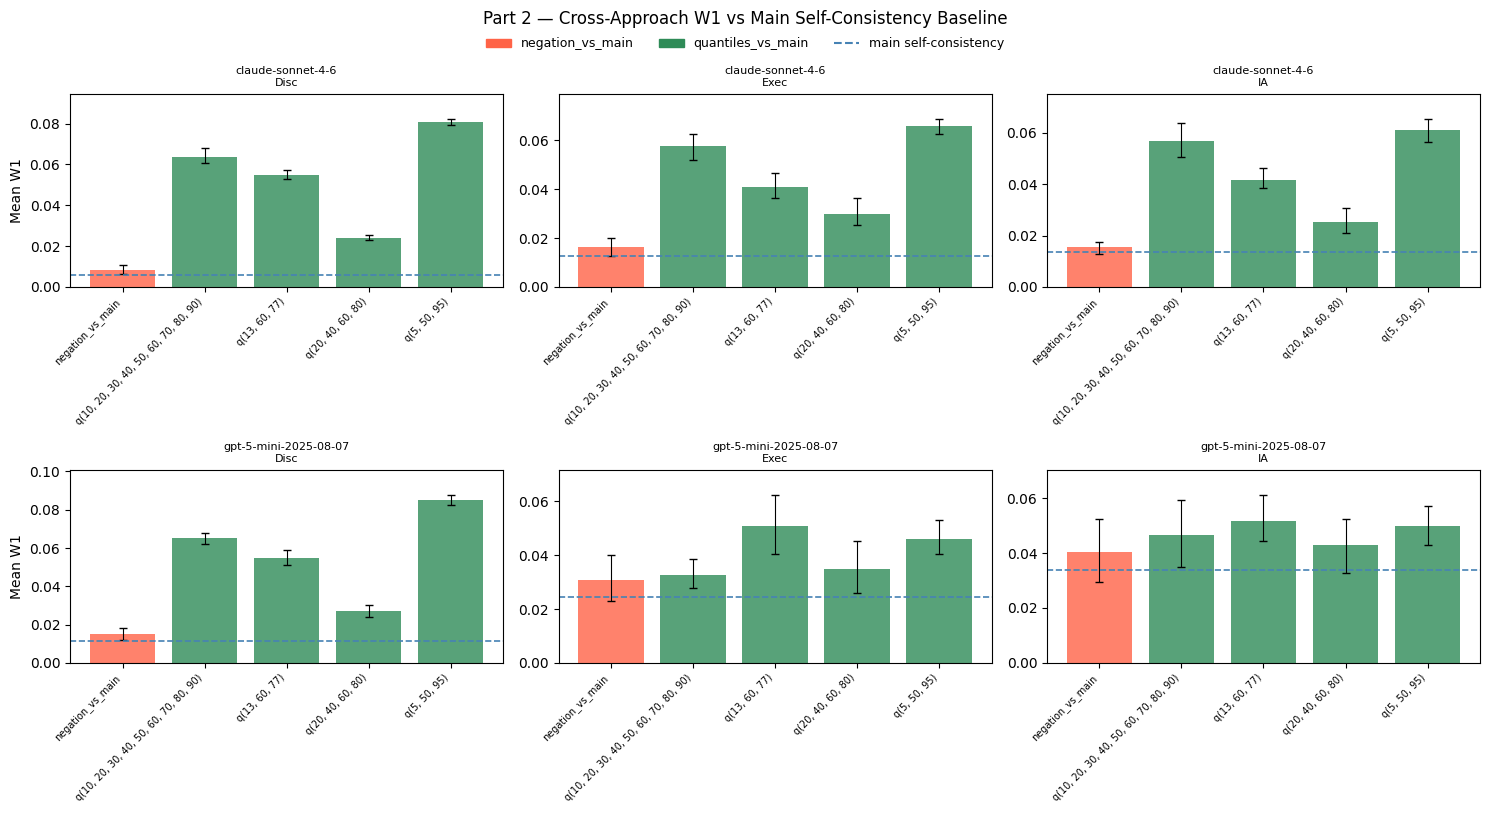

In [ ]:
# ── Part 2: visualise cross-approach vs self-consistency baseline (W1) ────────

cross_df["step_short"] = cross_df["step_name"].map(STEP_SHORT).fillna(cross_df["step_name"])
cross_df["condition"] = cross_df.apply(
    lambda r: r["comparison"] if r["quantile_config"] == "—"
    else f"q{r['quantile_config']}",
    axis=1,
)

# Self-consistency baseline for main (mean W1 per model + step)
main_sc = (
    sc_df[sc_df["source"] == "main"]
    .groupby(["model", "step_short"])["w1"]
    .mean()
    .reset_index()
    .rename(columns={"w1": "w1_baseline"})
)

fig, axes = plt.subplots(len(models), len(steps),
                         figsize=(5 * len(steps), 4 * len(models)),
                         squeeze=False)

COMP_COLOR = {"negation_vs_main": "tomato", "quantiles_vs_main": "seagreen"}

for row_i, model in enumerate(models):
    for col_i, step in enumerate(steps):
        ax = axes[row_i][col_i]
        sub = cross_df[
            (cross_df["model"] == model) & (cross_df["step_short"] == step)
        ].sort_values("condition")

        colors = [COMP_COLOR[c] for c in sub["comparison"]]
        xs = range(len(sub))
        ax.bar(xs, sub["w1"], color=colors, alpha=0.8)
        ax.errorbar(
            xs, sub["w1"],
            yerr=[sub["w1"] - sub["w1_ci_lower"], sub["w1_ci_upper"] - sub["w1"]],
            fmt="none", color="black", capsize=3, linewidth=0.8,
        )
        ax.set_xticks(xs)
        ax.set_xticklabels(sub["condition"], rotation=45, ha="right", fontsize=7)

        # dashed baseline: self-consistency of main
        bl = main_sc.loc[
            (main_sc["model"] == model) & (main_sc["step_short"] == step),
            "w1_baseline",
        ]
        if not bl.empty:
            ax.axhline(bl.values[0], color="steelblue", linestyle="--",
                       linewidth=1.2, label="main self-consistency")

        top = (sub["w1_ci_upper"]).max() * 1.15
        ax.set_ylim(bottom=0, top=top if not np.isnan(top) else None)
        ax.set_title(f"{model}\n{step}", fontsize=8)
        if col_i == 0:
            ax.set_ylabel("Mean W1")

legend_elements = [
    Patch(color="tomato",    label="negation_vs_main"),
    Patch(color="seagreen",  label="quantiles_vs_main"),
    Line2D([0], [0], color="steelblue", linestyle="--", label="main self-consistency"),
]
fig.legend(handles=legend_elements, loc="upper center",
           bbox_to_anchor=(.5, .99), ncol=len(legend_elements),
           frameon=False, fontsize=9)
fig.suptitle("Part 2 — Cross-Approach W1 vs Main Self-Consistency Baseline", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


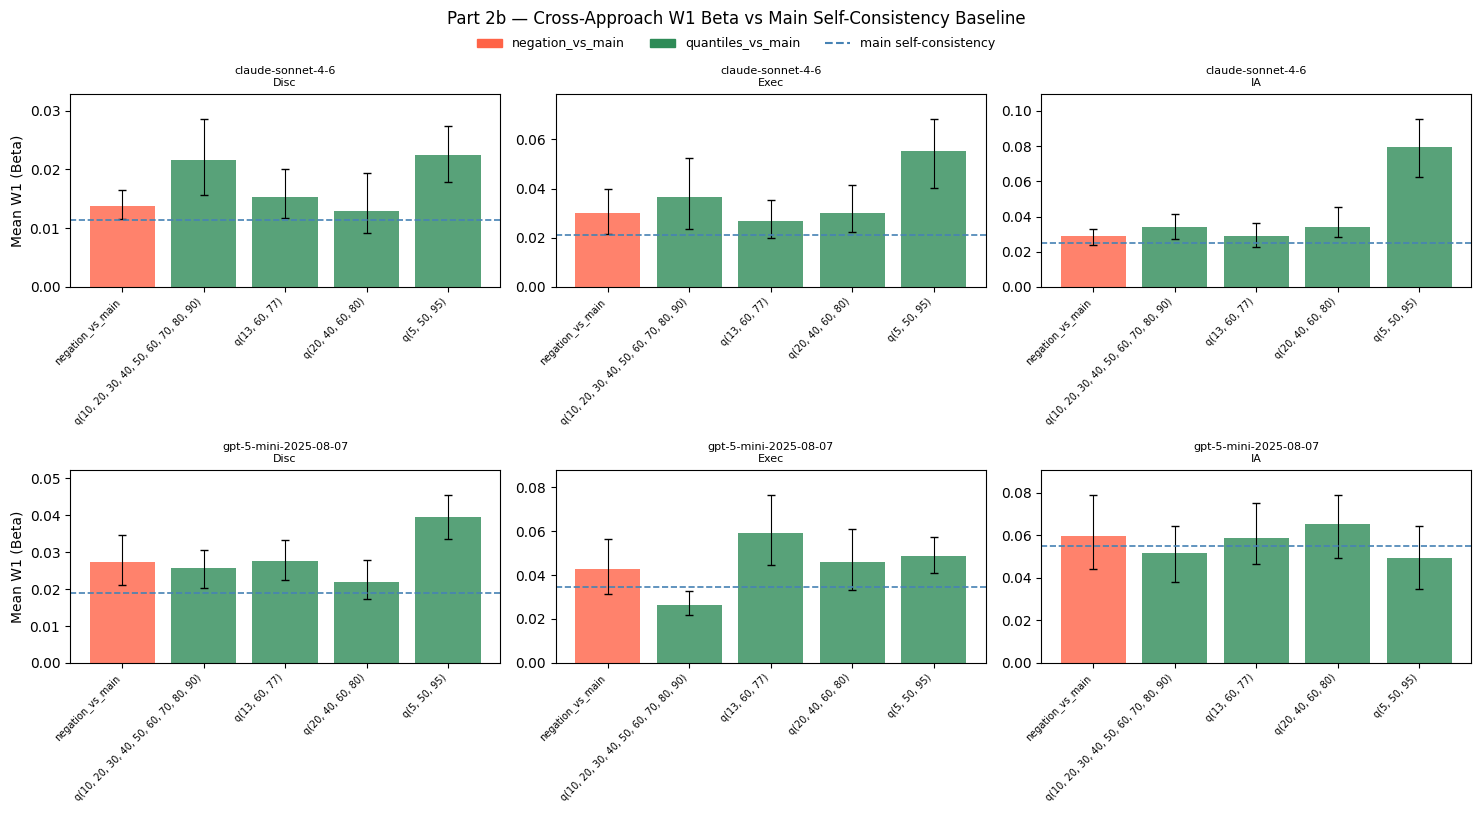

In [24]:
# ── Part 2b: visualise cross-approach vs self-consistency baseline (W1 Beta) ──

# Self-consistency baseline for main (mean W1_beta per model + step)
main_sc_beta = (
    sc_df[sc_df["source"] == "main"]
    .groupby(["model", "step_short"])["w1_beta"]
    .mean()
    .reset_index()
    .rename(columns={"w1_beta": "w1_beta_baseline"})
)

fig, axes = plt.subplots(len(models), len(steps),
                         figsize=(5 * len(steps), 4 * len(models)),
                         squeeze=False)

for row_i, model in enumerate(models):
    for col_i, step in enumerate(steps):
        ax = axes[row_i][col_i]
        sub = cross_df[
            (cross_df["model"] == model) & (cross_df["step_short"] == step)
        ].sort_values("condition")

        colors = [COMP_COLOR[c] for c in sub["comparison"]]
        xs = range(len(sub))
        ax.bar(xs, sub["w1_beta"], color=colors, alpha=0.8)
        ax.errorbar(
            xs, sub["w1_beta"],
            yerr=[sub["w1_beta"] - sub["w1_beta_ci_lower"],
                  sub["w1_beta_ci_upper"] - sub["w1_beta"]],
            fmt="none", color="black", capsize=3, linewidth=0.8,
        )
        ax.set_xticks(xs)
        ax.set_xticklabels(sub["condition"], rotation=45, ha="right", fontsize=7)

        # dashed baseline: self-consistency of main (beta)
        bl = main_sc_beta.loc[
            (main_sc_beta["model"] == model) & (main_sc_beta["step_short"] == step),
            "w1_beta_baseline",
        ]
        if not bl.empty:
            ax.axhline(bl.values[0], color="steelblue", linestyle="--",
                       linewidth=1.2, label="main self-consistency")

        top = (sub["w1_beta_ci_upper"]).max() * 1.15
        ax.set_ylim(bottom=0, top=top if not np.isnan(top) else None)
        ax.set_title(f"{model}\n{step}", fontsize=8)
        if col_i == 0:
            ax.set_ylabel("Mean W1 (Beta)")

legend_elements = [
    Patch(color="tomato",    label="negation_vs_main"),
    Patch(color="seagreen",  label="quantiles_vs_main"),
    Line2D([0], [0], color="steelblue", linestyle="--", label="main self-consistency"),
]
fig.legend(handles=legend_elements, loc="upper center",
           bbox_to_anchor=(.5, .99), ncol=len(legend_elements),
           frameon=False, fontsize=9)
fig.suptitle("Part 2b — Cross-Approach W1 Beta vs Main Self-Consistency Baseline", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


### Example distributions

Model: claude-sonnet-4-6, Step: TA0002 - Execution

Main vs Negation (inverted):
[[(0.25, 0.49), (0.5, 0.54), (0.75, 0.58)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


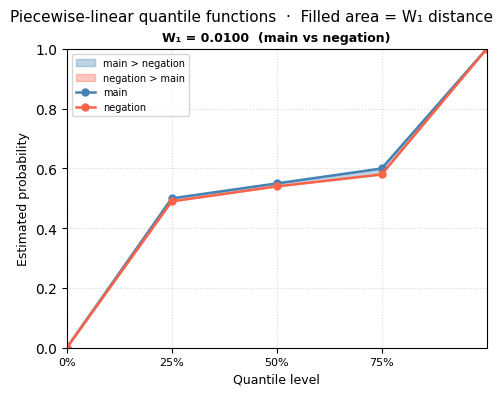


Main vs Quantiles (config (5, 50, 95)):
[[(0.05, 0.25), (0.5, 0.55), (0.95, 0.82)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


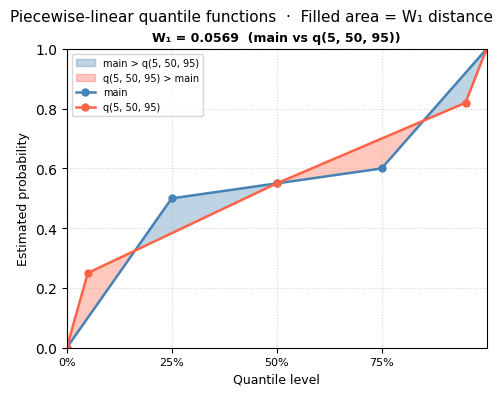


Main vs Quantiles (config (10, 20, 30, 40, 50, 60, 70, 80, 90)):
[[(0.1, 0.42), (0.2, 0.47), (0.3, 0.51), (0.4, 0.54), (0.5, 0.57), (0.6, 0.6), (0.7, 0.63), (0.8, 0.67), (0.9, 0.72)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


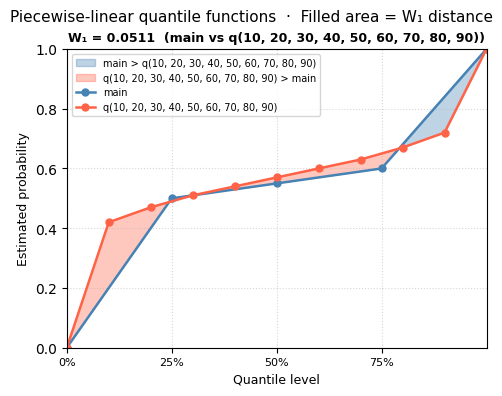


Main vs Quantiles (config (13, 60, 77)):
[[(0.13, 0.48), (0.6, 0.54), (0.77, 0.57)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


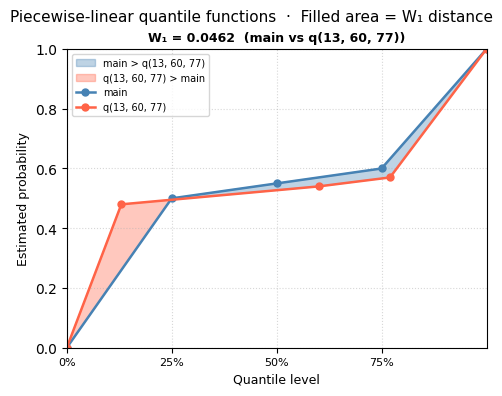


Main vs Quantiles (config (20, 40, 60, 80)):
[[(0.2, 0.49), (0.4, 0.53), (0.6, 0.57), (0.8, 0.62)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


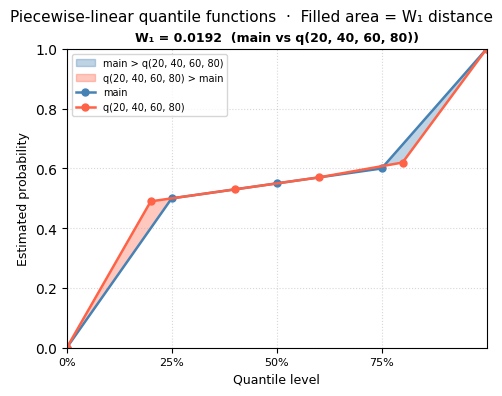

In [13]:
# ── Cross-approach CDF plots: main vs negation, main vs each quantile config ─

main_dist_cross  = [row_to_pairs(r) for r in main_rows["estimates"].values[:1]]
main_cross_labels = ["main"]

# --- Main vs Negation ---
neg_rows_cross = df_valid[
    (df_valid["source"] == "negation")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
].copy()
neg_rows_cross["estimates"] = neg_rows_cross["estimates"].apply(invert_estimates)
neg_dist_cross  = [row_to_pairs(r) for r in neg_rows_cross["estimates"].values[:1]]
neg_cross_labels = ["negation"]

print(f"Model: {model_ex}, Step: {step_ex}\n")

print("Main vs Negation (inverted):")
fig_neg_cross = plot_cdf_pairs(main_dist_cross, neg_dist_cross,
                               labels_a=main_cross_labels, labels_b=neg_cross_labels,
                               use_beta=False)
fig_neg_cross.subplots_adjust(top=0.88)
print(neg_dist_cross)
print(main_dist_cross)
plt.show()

# --- Main vs each Quantile config ---
quant_rows_cross = df_valid[
    (df_valid["source"] == "quantiles")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
]

for qconfig in sorted(quant_rows_cross["quantile_config"].unique()):
    quant_subset = quant_rows_cross[quant_rows_cross["quantile_config"] == qconfig]
    quant_dist  = [row_to_pairs(r) for r in quant_subset["estimates"].values[:1]]
    quant_label = [f"q{qconfig}"]

    print(f"\nMain vs Quantiles (config {qconfig}):")
    fig = plot_cdf_pairs(main_dist_cross, quant_dist,
                         labels_a=main_cross_labels, labels_b=quant_label,
                         use_beta=False)
    fig.subplots_adjust(top=0.88)
    print(quant_dist)
    print(main_dist_cross)
    plt.show()


Model: claude-sonnet-4-6, Step: TA0002 - Execution

Main vs Negation (inverted):
[[(0.25, 0.49), (0.5, 0.54), (0.75, 0.58)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


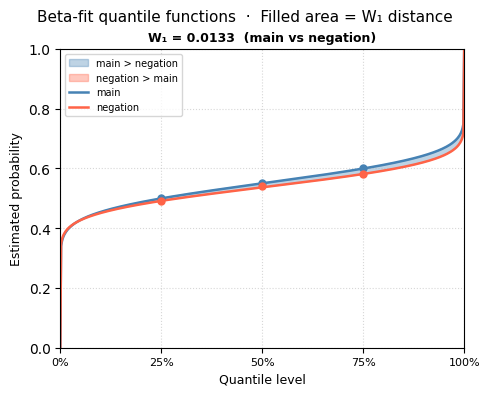


Main vs Quantiles (config (5, 50, 95)):
[[(0.05, 0.25), (0.5, 0.55), (0.95, 0.82)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


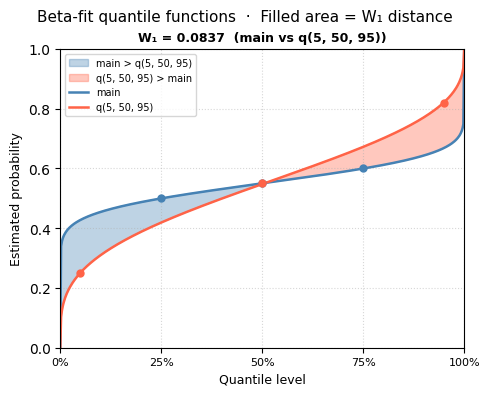


Main vs Quantiles (config (10, 20, 30, 40, 50, 60, 70, 80, 90)):
[[(0.1, 0.42), (0.2, 0.47), (0.3, 0.51), (0.4, 0.54), (0.5, 0.57), (0.6, 0.6), (0.7, 0.63), (0.8, 0.67), (0.9, 0.72)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


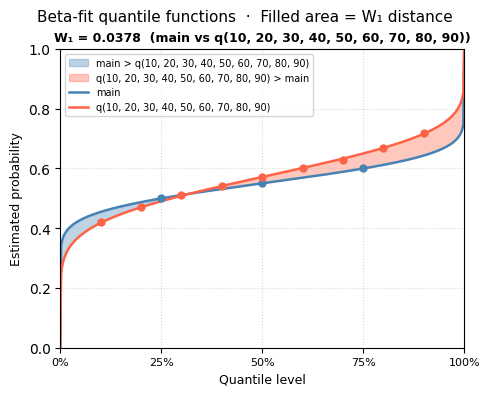


Main vs Quantiles (config (13, 60, 77)):
[[(0.13, 0.48), (0.6, 0.54), (0.77, 0.57)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


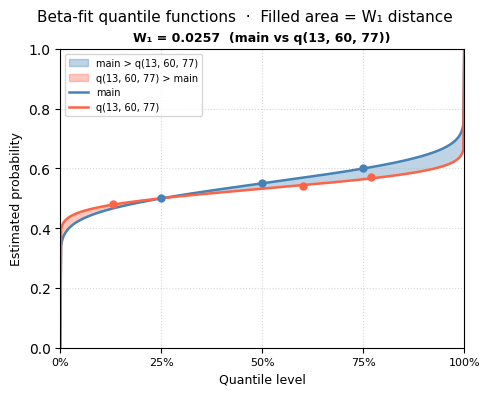


Main vs Quantiles (config (20, 40, 60, 80)):
[[(0.2, 0.49), (0.4, 0.53), (0.6, 0.57), (0.8, 0.62)]]
[[(0.25, 0.5), (0.5, 0.55), (0.75, 0.6)]]


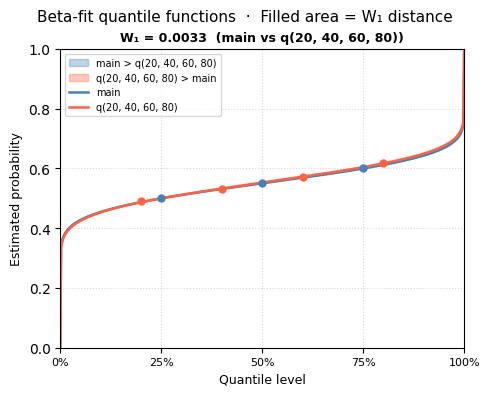

In [14]:
# ── Cross-approach CDF plots: main vs negation, main vs each quantile config ─

main_dist_cross  = [row_to_pairs(r) for r in main_rows["estimates"].values[:1]]
main_cross_labels = ["main"]

# --- Main vs Negation ---
neg_rows_cross = df_valid[
    (df_valid["source"] == "negation")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
].copy()
neg_rows_cross["estimates"] = neg_rows_cross["estimates"].apply(invert_estimates)
neg_dist_cross  = [row_to_pairs(r) for r in neg_rows_cross["estimates"].values[:1]]
neg_cross_labels = ["negation"]

print(f"Model: {model_ex}, Step: {step_ex}\n")

print("Main vs Negation (inverted):")
fig_neg_cross = plot_cdf_pairs(main_dist_cross, neg_dist_cross,
                               labels_a=main_cross_labels, labels_b=neg_cross_labels,
                               use_beta=True)
fig_neg_cross.subplots_adjust(top=0.88)
print(neg_dist_cross)
print(main_dist_cross)
plt.show()

# --- Main vs each Quantile config ---
quant_rows_cross = df_valid[
    (df_valid["source"] == "quantiles")
    & (df_valid["model"] == model_ex)
    & (df_valid["step_name"] == step_ex)
]

for qconfig in sorted(quant_rows_cross["quantile_config"].unique()):
    quant_subset = quant_rows_cross[quant_rows_cross["quantile_config"] == qconfig]
    quant_dist  = [row_to_pairs(r) for r in quant_subset["estimates"].values[:1]]
    quant_label = [f"q{qconfig}"]

    print(f"\nMain vs Quantiles (config {qconfig}):")
    fig = plot_cdf_pairs(main_dist_cross, quant_dist,
                         labels_a=main_cross_labels, labels_b=quant_label,
                         use_beta=True)
    fig.subplots_adjust(top=0.88)
    print(quant_dist)
    print(main_dist_cross)
    plt.show()



Main vs Quantiles (config (5, 50, 95)) — specific example:


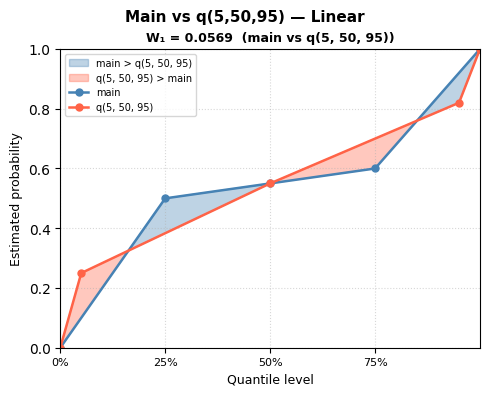

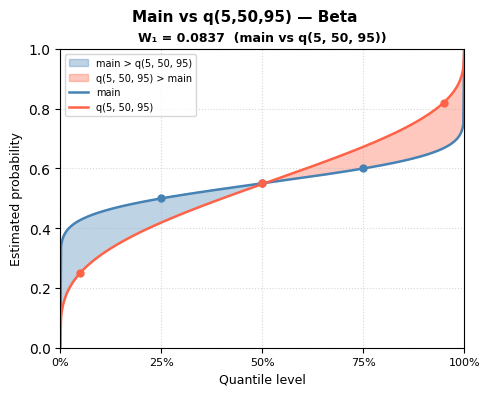

In [18]:
# --- Specific example: quantiles config (5, 50, 95) ---
qconfig_target = (5, 50, 95)
quant_target = quant_rows_cross[quant_rows_cross["quantile_config"] == qconfig_target]
if not quant_target.empty:
    quant_dist_target = [row_to_pairs(r) for r in quant_target["estimates"].values[:1]]
    quant_label_target = [f"q{qconfig_target}"]

    print(f"\nMain vs Quantiles (config {qconfig_target}) — specific example:")
    fig = plot_cdf_pairs(main_dist_cross, quant_dist_target,
                         labels_a=main_cross_labels, labels_b=quant_label_target,
                         use_beta=False)
    fig.suptitle(f"Main vs q(5,50,95) — Linear", fontsize=11, fontweight="bold")
    fig.subplots_adjust(top=0.88)
    plt.show()

    fig_beta = plot_cdf_pairs(main_dist_cross, quant_dist_target,
                              labels_a=main_cross_labels, labels_b=quant_label_target,
                              use_beta=True)
    fig_beta.suptitle(f"Main vs q(5,50,95) — Beta", fontsize=11, fontweight="bold")
    fig_beta.subplots_adjust(top=0.88)
    plt.show()
else:
    print("No data found for quantile config (5, 50, 95)")


### Part 3 — Summary comparison: biggest sources of variance

Aggregate everything into a single ranked table and chart. Each row is one "condition" (a source + optional quantile config, or a cross-approach comparison). Conditions are ranked by mean W1 across models and steps so the largest contributors to variance stand out.

=== Part 3: Summary — all conditions ranked by mean W1 ===


,kind,condition,w1,w2,w1_beta,w2_beta,p50_divergence,iqr_divergence,w1_ci_lower,w1_ci_upper,w2_ci_lower,w2_ci_upper,w1_beta_ci_lower,w1_beta_ci_upper,w2_beta_ci_lower,w2_beta_ci_upper
0,cross-approach,"quantiles_vs_main (5, 50, 95)",0.0647,0.1041,0.0491,0.0613,0.0202,0.0926,0.0607,0.0690,0.0984,0.1110,0.0383,0.0597,0.0472,0.0752
1,cross-approach,"quantiles_vs_main (10, 20, 30, 40, 50, 60, 70,...",0.0538,0.0862,0.0326,0.0401,0.0188,0.0474,0.0481,0.0601,0.0779,0.0947,0.0244,0.0417,0.0294,0.0519
2,cross-approach,"quantiles_vs_main (13, 60, 77)",0.0491,0.0793,0.0361,0.0434,0.0288,0.0513,0.0439,0.0555,0.0724,0.0872,0.0279,0.0461,0.0335,0.0552
3,cross-approach,"quantiles_vs_main (20, 40, 60, 80)",0.0307,0.0421,0.0350,0.0415,0.0285,0.0483,0.0253,0.0367,0.0356,0.0492,0.0266,0.0456,0.0314,0.0546
4,self-consistency,"quantiles (13, 60, 77)",0.0238,0.0291,0.0322,0.0380,0.0199,0.0455,0.0130,0.0287,0.0159,0.0350,0.0177,0.0387,0.0207,0.0459
5,self-consistency,"quantiles (5, 50, 95)",0.0227,0.0267,0.0254,0.0292,0.0185,0.0327,0.0125,0.0268,0.0150,0.0312,0.0139,0.0300,0.0160,0.0344
6,cross-approach,negation_vs_main,0.0210,0.0257,0.0337,0.0407,0.0212,0.0466,0.0160,0.0264,0.0196,0.0320,0.0257,0.0431,0.0306,0.0525
7,self-consistency,"quantiles (10, 20, 30, 40, 50, 60, 70, 80, 90)",0.0203,0.0247,0.0238,0.0286,0.0160,0.0349,0.0114,0.0241,0.0142,0.0292,0.0129,0.0288,0.0152,0.0347
8,self-consistency,"quantiles (20, 40, 60, 80)",0.0193,0.0232,0.0269,0.0316,0.0198,0.0342,0.0110,0.0230,0.0131,0.0279,0.0143,0.0329,0.0162,0.0394
9,self-consistency,negation,0.0189,0.0225,0.0280,0.0326,0.0238,0.0312,0.0110,0.0223,0.0134,0.0260,0.0170,0.0320,0.0195,0.0373


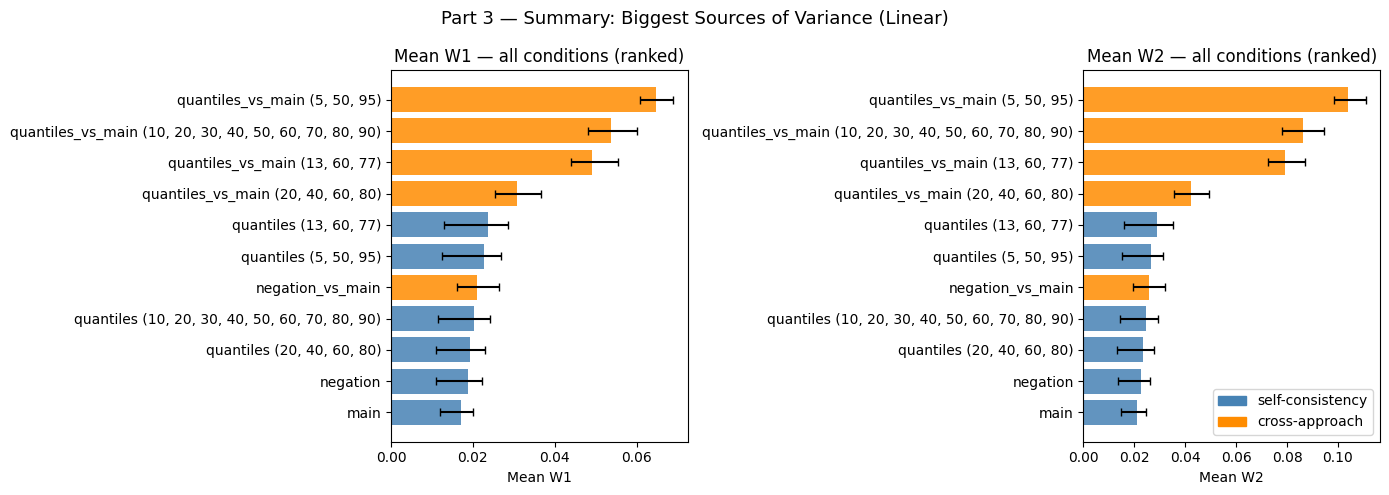

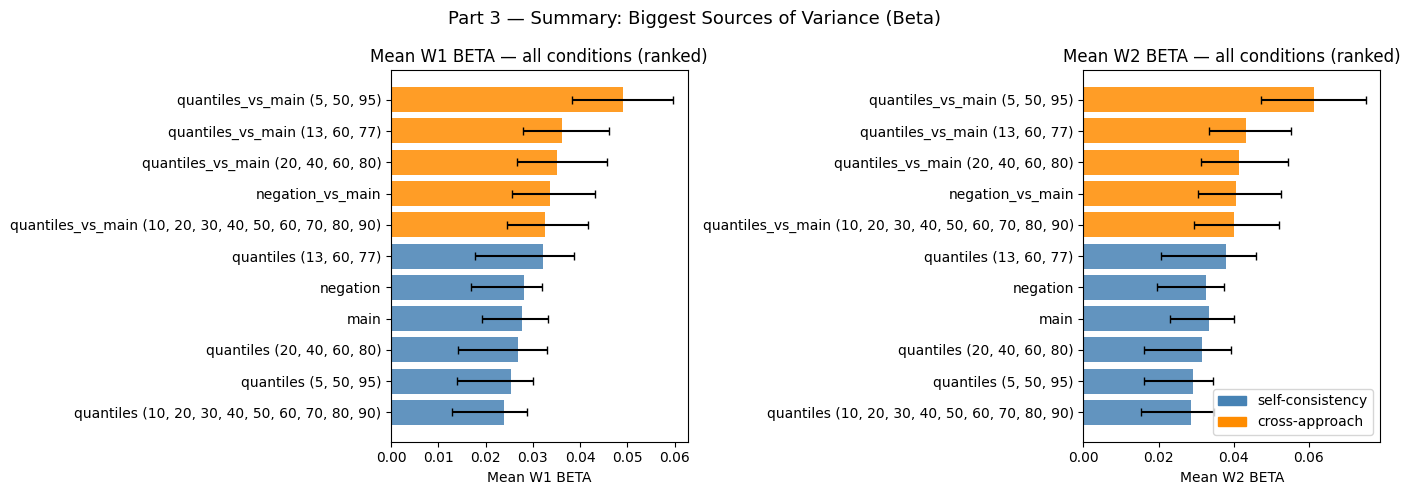

In [29]:
# ── Part 3: summary — rank all variance sources ───────────────────────────────

METRIC_COLS = ["w1", "w2", "w1_beta", "w2_beta", "p50_divergence", "iqr_divergence"]
CI_COLS = [f"{m}_{b}" for m in ["w1", "w2", "w1_beta", "w2_beta"] for b in ["ci_lower", "ci_upper"]]
ALL_COLS = METRIC_COLS + CI_COLS

# Self-consistency entries (averaged over model+step)
sc_agg = (
    sc_df.groupby(["source", "quantile_config"])[ALL_COLS]
    .mean()
    .reset_index()
)

sc_agg["kind"] = "self-consistency"
sc_agg["condition"] = sc_agg.apply(
    lambda r: r["source"] if r["quantile_config"] == "—"
    else f"{r['source']} {r['quantile_config']}",
    axis=1,
)

# Cross-approach entries (averaged over model+step)
cross_agg = (
    cross_df.groupby(["comparison", "quantile_config"])[ALL_COLS]
    .mean()
    .reset_index()
)

cross_agg["kind"] = "cross-approach"
cross_agg["condition"] = cross_agg.apply(
    lambda r: r["comparison"] if r["quantile_config"] == "—"
    else f"{r['comparison']} {r['quantile_config']}",
    axis=1,
)

summary = (
    pd.concat(
        [sc_agg[["kind", "condition"] + ALL_COLS],
         cross_agg[["kind", "condition"] + ALL_COLS]],
        ignore_index=True,
    )
    .sort_values("w1", ascending=False)
    .reset_index(drop=True)
)


print("=== Part 3: Summary — all conditions ranked by mean W1 ===")
display(summary.round(4))

# ── Ranked bar charts: linear W1/W2 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.4 * len(summary))))

for ax, metric in zip(axes, ["w1", "w2"]):
    colors = [
        "steelblue" if k == "self-consistency" else "darkorange"
        for k in summary["kind"]
    ]
    ax.barh(summary["condition"], summary[metric], xerr=[
        summary[metric] - summary[f"{metric}_ci_lower"],
        summary[f"{metric}_ci_upper"] - summary[metric],
    ], color=colors, alpha=0.85, capsize=3, ecolor="black")

    ax.set_xlabel(f"Mean {metric.upper()}")
    ax.set_title(f"Mean {metric.upper()} — all conditions (ranked)")
    ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(color="steelblue",   label="self-consistency"),
    Patch(color="darkorange",  label="cross-approach"),
]
axes[1].legend(handles=legend_elements, loc="lower right")
plt.suptitle("Part 3 — Summary: Biggest Sources of Variance (Linear)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Ranked bar charts: beta W1/W2 ────────────────────────────────────────────
summary_beta = summary.sort_values("w1_beta", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.4 * len(summary_beta))))

for ax, metric in zip(axes, ["w1_beta", "w2_beta"]):
    colors = [
        "steelblue" if k == "self-consistency" else "darkorange"
        for k in summary_beta["kind"]
    ]
    ax.barh(summary_beta["condition"], summary_beta[metric], xerr=[
        summary_beta[metric] - summary_beta[f"{metric}_ci_lower"],
        summary_beta[f"{metric}_ci_upper"] - summary_beta[metric],
    ], color=colors, alpha=0.85, capsize=3, ecolor="black")

    ax.set_xlabel(f"Mean {metric.replace('_', ' ').upper()}")
    ax.set_title(f"Mean {metric.replace('_', ' ').upper()} — all conditions (ranked)")
    ax.invert_yaxis()

axes[1].legend(handles=legend_elements, loc="lower right")
plt.suptitle("Part 3 — Summary: Biggest Sources of Variance (Beta)", fontsize=13)
plt.tight_layout()
plt.show()
